### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
# since there are a lot of columns and it makes it hard to view them all at once, filter to just numerical columns
data.select_dtypes(include='int64').head()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,55,1,1,0,0,0,1,1
1,80,1,1,0,0,0,1,0
2,80,1,1,1,0,0,1,1
3,80,1,1,1,0,0,1,0
4,80,1,1,1,0,0,1,0


In [6]:
# view just object (seems to be mostly strings) columns, to get a sense of the data in these columns
data.select_dtypes(include='object').head()

,destination,passanger,weather,time,coupon,expiration,gender,age,maritalStatus,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
0,No Urgent Place,Alone,Sunny,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3
1,No Urgent Place,Friend(s),Sunny,10AM,Coffee House,2h,Female,21,Unmarried partner,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3
2,No Urgent Place,Friend(s),Sunny,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3
3,No Urgent Place,Friend(s),Sunny,2PM,Coffee House,2h,Female,21,Unmarried partner,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3
4,No Urgent Place,Friend(s),Sunny,2PM,Coffee House,1d,Female,21,Unmarried partner,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3


2. Investigate the dataset for missing or problematic data.

In [7]:
# list the number of null values in each column
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

For the car column, the majority of values are null (only 1% are filled), which makes it not very useful, so we will plan to drop that column. For the remaining ones, <2% of rows are null, so I'll explore the distribution of values in each column to decide what to do.

In [8]:
data['Bar'].value_counts()

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64

In [9]:
data['CoffeeHouse'].value_counts()

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64

In [10]:
data['CarryAway'].value_counts()

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64

In [11]:
data['RestaurantLessThan20'].value_counts()

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64

In [12]:
data['Restaurant20To50'].value_counts()

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [13]:
# since only 1% of rows have a car value, just drop this column
data = data.drop(columns=['car'])

For the remaining columns that have null values, there's a small number (<2%) that are null. While we could use the mode to fill those values, there is a pretty wide distribution of answers for each (see the value counts below), and this might impact the data since someone who answers "never" to going to a bar will likely have a different willingness to use a bar coupon than someone who did not answer (and same with the other columns). To keep this data more accurate, fill the null values with "not given".

In [14]:
data = data.fillna('not given')

In [15]:
# confirm there are no more null values
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [250]:
# since the "accept" column (Y) uses 1 for accept and 0 for rejects, we can sum the value of the column to get the total number of "accepts"
data['Y'].sum()

np.int64(7210)

In [23]:
# to get the proportion of accepts, divide the number that accept by the total number of observations (the first value of the shape)
acc_rate = data['Y'].sum() / data.shape[0]
print(f"Acceptance rate for all observations: {acc_rate*100:.2f}%")

Acceptance rate for all observations: 56.84%


5. Use a bar plot to visualize the `coupon` column.

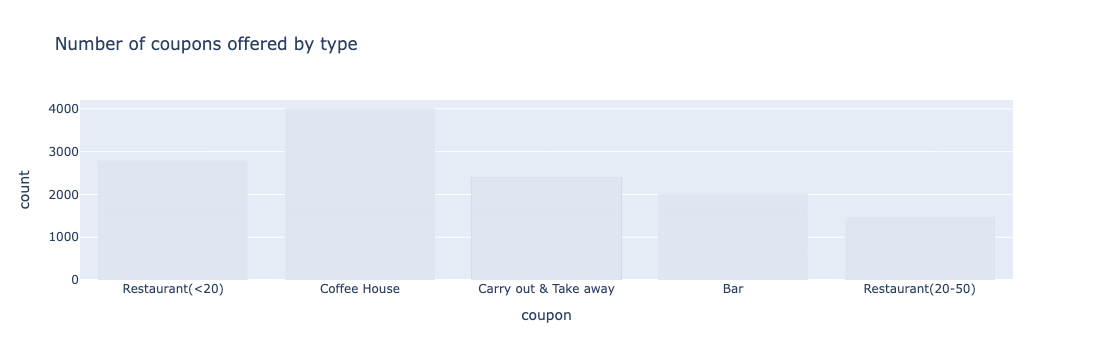

In [22]:
px.bar(data, x='coupon', title="Number of coupons offered by type")

6. Use a histogram to visualize the temperature column.

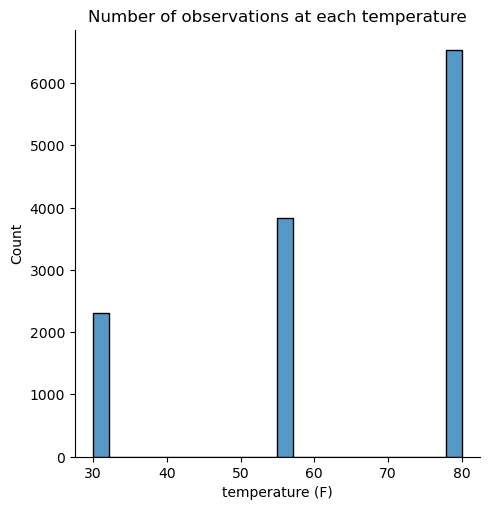

In [23]:
temp_plt = sns.displot(data, x='temperature')
temp_plt.set(title="Number of observations at each temperature", xlabel="temperature (F)")
temp_plt.savefig('images/temp.png')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [24]:
# query for just the bar coupons
bar_data = data.query('coupon == "Bar"')
bar_data.shape

(2017, 25)

2. What proportion of bar coupons were accepted?


In [25]:
# use the same proportion calculation on just the bar coupon data - number of accepts over number of observations
bar_acc_rate = bar_data['Y'].sum() / bar_data.shape[0]
print(f"Overall acceptance rate for bar coupons: {bar_acc_rate*100:.2f}%")

Overall acceptance rate for bar coupons: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [26]:
# create value arrays for <=3, and >3 - ignore people with "not given" values
lte3 = ['never', 'less1', '1~3']
gt3 = ['4~8', 'gt8']
# create dataframes for the people in each group
bar_lte_3 = bar_data.query('Bar in @lte3')
bar_gt_3 = bar_data.query('Bar in @gt3')

In [27]:
# use the proportion calculation to get the acceptance rate
bar_lte_3_acc = bar_lte_3['Y'].sum() / bar_lte_3.shape[0]
bar_gt_3_acc = bar_gt_3['Y'].sum() / bar_gt_3.shape[0]
print(f"Acceptance rate for people who go to the bar <=3 times/month: {bar_lte_3_acc*100:.2f}%")
print(f"Acceptance rate for people who go to the bar >3 times/month: {bar_gt_3_acc*100:.2f}%")

Acceptance rate for people who go to the bar <=3 times/month: 37.06%
Acceptance rate for people who go to the bar >3 times/month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [28]:
# create value arrays for >=1, and <1 
gt1 = ['1~3', '4~8', 'gt8']
lt1 = ['less1', 'never']
# create an array fo the values for age >25
age_gt25 = ['26', '31', '36', '41', '46', '50plus']

In [31]:
# create data frames for people in those groups
data_gt1_bar_gt25 = bar_data.query('Bar in @gt1 and age in @age_gt25')
gt1_bar_gt_25_acceptance_rate = data_gt1_bar_gt25['Y'].sum() / data_gt1_bar_gt25.shape[0]
print(f"Acceptance rate for people over 25 who go to the bar >1 time/month: {gt1_bar_gt_25_acceptance_rate*100:.2f}%")

Acceptance rate for people over 25 who go to the bar >1 time/month: 69.52%


In [32]:
# create data frames for people not in those groups
data_not_gt1_not_gt25 = bar_data.query('(Bar not in @gt1) or (age not in @age_gt25)')
not_gt1_not_gt25_acceptance_rate = data_not_gt1_not_gt25['Y'].sum() / data_not_gt1_not_gt25.shape[0]
print(f"Acceptance rate for the people outside of that group (either not >1 bar visit/month or not >25): {not_gt1_not_gt25_acceptance_rate*100:.2f}%")

Acceptance rate for the people outside of that group (either not >1 bar visit/month or not >25): 33.50%


The acceptance rate for people who go to the bar >1 time/month and are over 25 is 69.52%, which is significantly higher than the overall acceptance rate for bar coupons (41.00%). I also looked at the acceptance rate for people not in that group (i.e. they either don't have >1 bar visit/month, or they aren't over 25, or both), and the acceptance rate is 33.50%, even lower than the overall acceptance rate for bar coupons.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [33]:
# the passenger column is mispelled, so rename it to use the correct spelling
bar_data = bar_data.rename(columns={'passanger': 'passenger'})

In [34]:
# having a passenger who is not a kid implies means we should exclude people who have a kid passenger, or are alone
kid_or_alone = ['Kid(s)', 'Alone']
bar_no_kids_no_farm = bar_data.query('Bar in @gt1 and passenger not in @kid_or_alone and occupation != "Farming Fishing & Forestry"')
bar_no_kids_no_farm_acc_rate = bar_no_kids_no_farm['Y'].sum() / bar_no_kids_no_farm.shape[0]
print(f"Acceptance rate for drivers who go to bars >1 time/month, have passengers that are not a kid, and are not in farming, fishing, and forestry: {bar_no_kids_no_farm_acc_rate*100:.2f}%")

Acceptance rate for drivers who go to bars >1 time/month, have passengers that are not a kid, and are not in farming, fishing, and forestry: 71.79%


In [37]:
# having a passenger who is not a kid implies means we should exclude people who have a kid passenger, or are alone
bar_kids_alone_fff = bar_data.query('(Bar not in @gt1) or (passenger in @kid_or_alone) or (occupation == "Farming Fishing & Forestry")')
bar_kids_alone_fff_acc_rate = bar_kids_alone_fff['Y'].sum() / bar_kids_alone_fff.shape[0]
print(f"Acceptance rate for drivers not in this group (who go to bars <=1 time/month, have a kid passenger or are alone, or are in farming, fishing, and forestry: {bar_kids_fff_acc_rate*100:.2f}%")

Acceptance rate for drivers not in this group (who go to bars <=1 time/month, have a kid passenger or are alone, or are in farming, fishing, and forestry: 37.71%


The acceptance rate for people who go to a bar >1 time/month, have a passenger that's not a kid, and are not in farming, fishing, and forestry is 71.79%, which is significantly higher than the overall acceptance rate for bar coupons (41.00%). The people not in that group (who did not meet one or more of that criteria) have an acceptance rate of 37.71%, which is slightly lower than the overall acceptance rate.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [40]:
# create value arrays for the age, visits, and income specified in the groups
age_lt30 = ['21', '26', 'below21']
gt4 = ['4~8', 'gt8']
income_lt50 = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']
# query the bar statement for people in any of the groups above
bar_ors = bar_data.query('(Bar in @gt1 and passenger not in @kid_or_alone and maritalStatus != "Widowed") or (Bar in @gt1 and age in @age_lt30) or (RestaurantLessThan20 in @gt4 and income in @income_lt50)')
bar_ors_acc_rate = bar_ors['Y'].sum() / bar_ors.shape[0]
print(f"Acceptance rate for people in the specified groups: {bar_ors_acc_rate*100:.2f}%")

Acceptance rate for people in the specified groups: 56.93%


In [42]:
# to better understand the breakdown of factors, look at the acceptance rate for each of these "or-ed" groups individually
bar_no_kid_no_widow = bar_data.query('Bar in @gt1 and passenger not in @kid_or_alone and maritalStatus != "Widowed"')
group1_acc_rate = bar_no_kid_no_widow['Y'].sum() / bar_no_kid_widow.shape[0]
bar_lt_30 = bar_data.query('Bar in @gt1 and age in @age_lt30')
group2_acc_rate = bar_lt_30['Y'].sum() / bar_lt_30.shape[0]
rest_lt_50k = bar_data.query('RestaurantLessThan20 in @gt4 and income in @income_lt50')
group3_acc_rate = rest_lt_50k['Y'].sum() / rest_lt_50k.shape[0]
print(f"The acceptance rates for the individual groups or-ed in question 6, in order: {group1_acc_rate*100:.2f}%, {group2_acc_rate*100:.2f}%, {group3_acc_rate*100:.2f}%")

The acceptance rates for the individual groups or-ed in question 6, in order: 71.79%, 72.17%, 45.35%


For question 6, I looked at the total acceptance rate for the or-ed groups, which was 56.93%, higher than the overall acceptance rate. When I broke down each group, the first two groups have significantly higher acceptance rates - over 70%, whereas the third group (goes to cheap restaurants more than 4 times/month and has income <50k) had a lower acceptance rate of 45.35%, which is just slightly higher than the overall acceptance rate for bar coupons.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the observations from above, I hypothesize that people who go to bars more than once a month are significantly more likely to accept a bar coupon. This is especially true for people who are under the age of 30 and had a passenger in the car that was not a kid.
Below are some additional plots to help visualize who accepted the coupon based on specific demographics like age, marital status, and passenger. From looking at this data, my hypothesis is that people aged 21-25, people who are single, and people with a friend in the car are most likely to accept a bar coupon. Income does not seem to have a strong correlation with acceptance rate, and occupation had a wide range of acceptance rates, with the exception of unemployed people who are very unlikely to accept a coupon. Additionally, if someone is headed home and the coupon is in the direction they're headed, they are more likely to accept than if it's in the opposite direction, or they're headed to work.
Based on this, I would suggest targeting bar coupons at people who go to a bar at least once a month, are under 30, and have a friend or partner in the car. I would target them when they're headed home, and with coupons for the direction they are already headed.

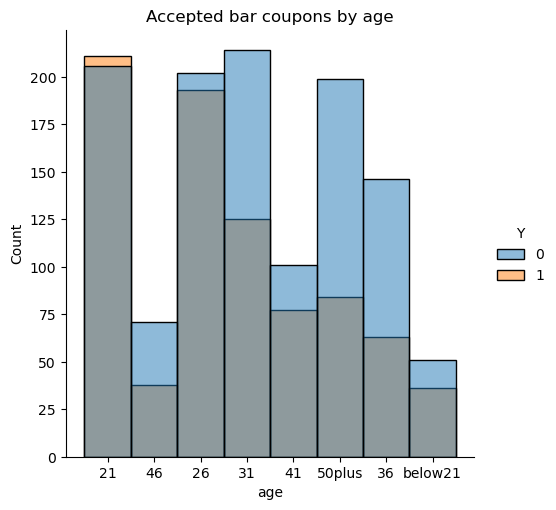

In [55]:
bar_age_hist = sns.displot(bar_data, x='age', hue='Y').set(title='Accepted bar coupons by age')
bar_age_hist.savefig('images/bar/bar_age_hist.png')

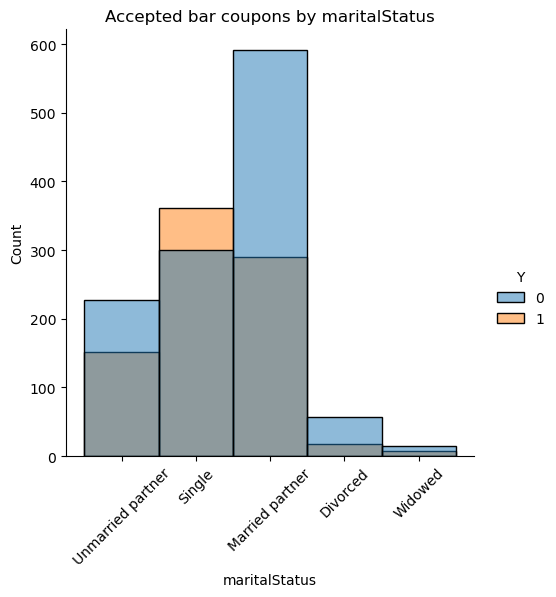

In [56]:
bar_marital_hist = sns.displot(bar_data, x='maritalStatus', hue='Y').set(title='Accepted bar coupons by maritalStatus')
bar_marital_hist.tick_params(axis='x', labelrotation=45)
bar_marital_hist.savefig('images/bar/bar_marital_hist.png')

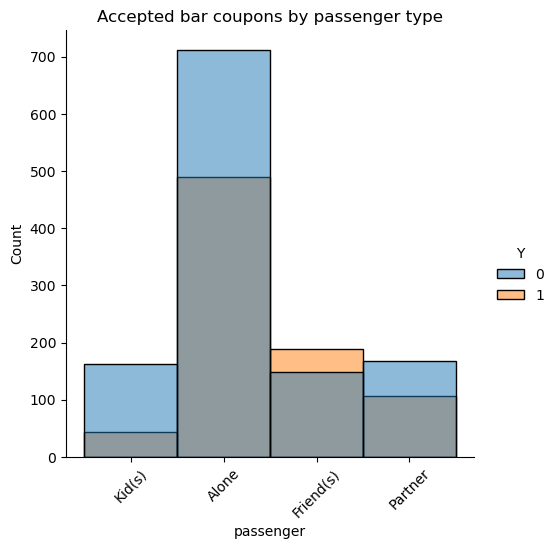

In [46]:
bar_passenger_hist = sns.displot(bar_data, x='passenger', hue='Y').set(title='Accepted bar coupons by passenger type')
bar_passenger_hist.tick_params(axis='x', labelrotation=45)
bar_passenger_hist.savefig('images/bar_passenger_hist.png')

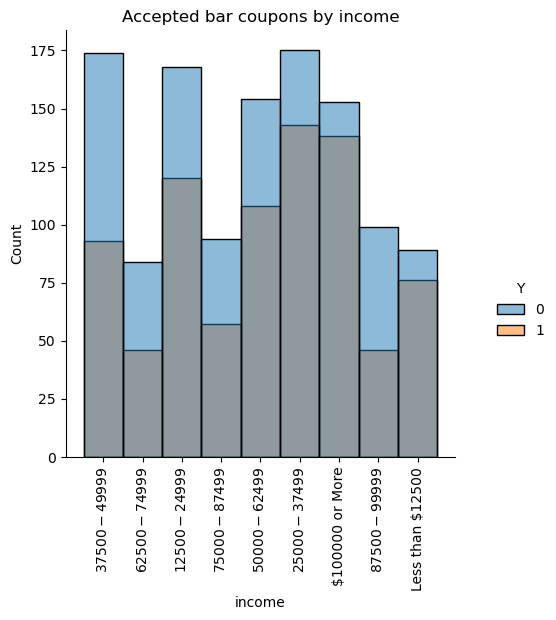

In [57]:
bar_income_hist = sns.displot(bar_data, x='income', hue='Y').set(title='Accepted bar coupons by income')
bar_income_hist.tick_params(axis='x', labelrotation=90)
bar_income_hist.savefig('images/bar/bar_income_hist.png')

Acceptance rate if unemployed: 30.23%, if retired: 24.00%, if employed: 43.75%


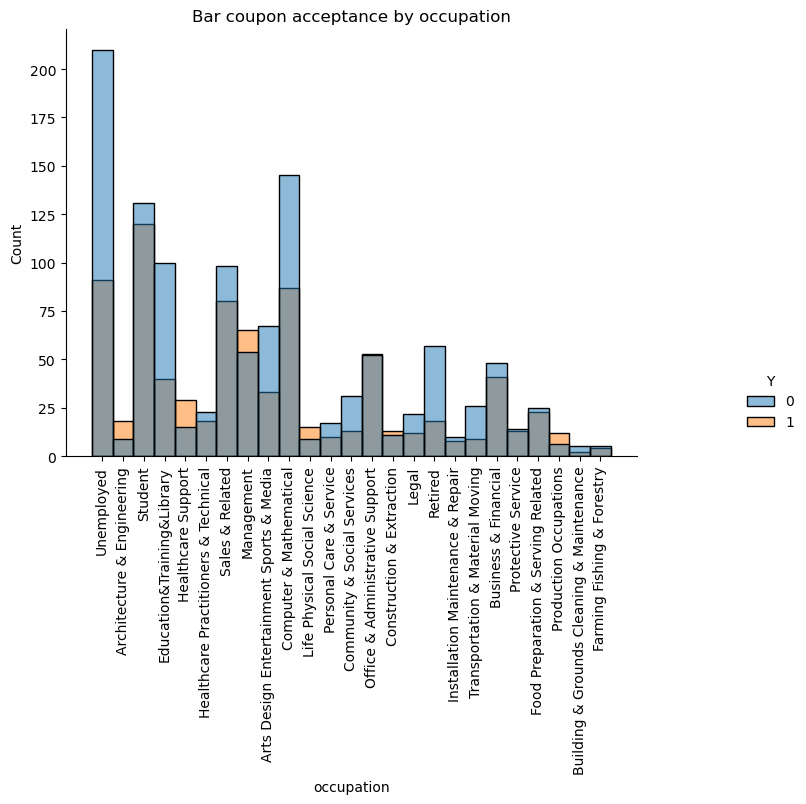

In [58]:
unemp = bar_data.query('occupation == "Unemployed"')
unemp_acc = unemp['Y'].sum() / unemp.shape[0]
retired = bar_data.query('occupation == "Retired"')
retired_acc = retired['Y'].sum() / retired.shape[0]
emp = bar_data.query('occupation != "Unemployed" and occupation != "Retired"')
emp_acc = emp['Y'].sum() / emp.shape[0]
print(f"Acceptance rate if unemployed: {unemp_acc*100:.2f}%, if retired: {retired_acc*100:.2f}%, if employed: {emp_acc*100:.2f}%")
bar_occupation_hist = sns.displot(bar_data, x='occupation', hue='Y', height=5, aspect=1.5)
bar_occupation_hist.tick_params(axis='x', labelrotation=90).set(title="Bar coupon acceptance by occupation")
bar_occupation_hist.savefig('images/bar/bar_occupation_hist.png')

In [59]:
bar_home = bar_data.query('destination == "Home"')
bar_home_acc = bar_home['Y'].sum() / bar_home.shape[0]
bar_no_place = bar_data.query('destination == "No Urgent Place"')
bar_no_place_acc = bar_no_place['Y'].sum() / bar_no_place.shape[0]
bar_home_dir_same = bar_home.query('direction_same == 1')
bar_home_dir_same_acc = bar_home_dir_same['Y'].sum() / bar_home_dir_same.shape[0]
bar_home_dir_opp = bar_home.query('direction_opp == 1')
bar_home_dir_opp_acc = bar_home_dir_opp['Y'].sum() / bar_home_dir_opp.shape[0]
bar_work = bar_data.query('destination == "Work"')
bar_work_acc = bar_work['Y'].sum() / bar_work.shape[0]
print(f"Bar acceptance rate if heading home: {bar_home_acc*100:.2f}% (if in the opposite direction: {bar_home_dir_opp_acc*100:.2f}%, if same direction: {bar_home_dir_same_acc*100:.2f}%). If heading to work: {bar_work_acc*100:.2f}%, and if no urgent place to be: {bar_no_place_acc*100:.2f}%")

Bar acceptance rate if heading home: 45.65% (if in the opposite direction: 36.99%, if same direction: 50.15%). If heading to work: 36.55%, and if no urgent place to be: 40.82%


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [60]:
# filter for just coffee house coupons to explore that data
ch_data = data.query('coupon == "Coffee House"')

In [52]:
acc_rate = ch_data['Y'].sum() / ch_data.shape[0]
print(f"Overall acceptance rate for coffeehouse coupons: {acc_rate*100:.2f}%")

Overall acceptance rate for coffeehouse coupons: 49.92%


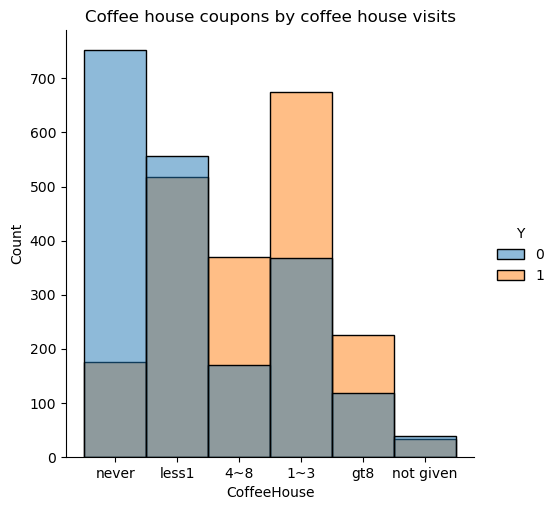

In [61]:
ch_visits_hist = sns.displot(ch_data, x='CoffeeHouse', hue='Y').set(title='Coffee house coupons by coffee house visits')
ch_visits_hist.savefig('images/coffee/coffee_house_visits_hist.png')

In [103]:
ch_visits_gte4 = ch_data.query('CoffeeHouse in @gt4')
ch_visits_gte4_acc_rate = ch_visits_gte4['Y'].sum() / ch_visits_gte4.shape[0]
ch_visits_lt4 = ch_data.query('CoffeeHouse not in @gt4')
ch_visits_lt4_acc_rate = ch_visits_lt4['Y'].sum() / ch_visits_lt4.shape[0]
print(f"Acceptance rate for people who visited coffee shops >=4 times/month: {ch_visits_gte4_acc_rate*100:.2f}%")
print(f"Acceptance rate for people who visited coffee shops <4 times/month: {ch_visits_lt4_acc_rate*100:.2f}%")

Acceptance rate for people who visited coffee shops >=4 times/month: 67.50%
Acceptance rate for people who visited coffee shops <4 times/month: 44.96%


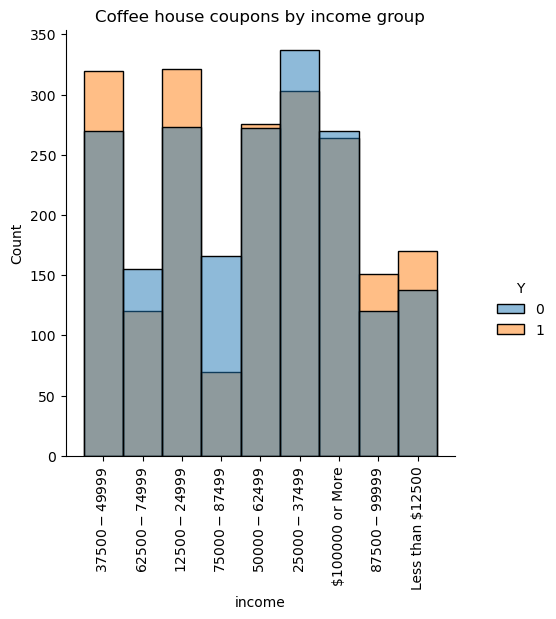

In [62]:
ch_income_hist = sns.displot(ch_data, x='income', hue='Y')
ch_income_hist.set(title='Coffee house coupons by income group')
ch_income_hist.tick_params(axis='x', labelrotation=90)
ch_income_hist.savefig('images/coffee/ch_income_hist.png')

In [63]:
ch_income_lt50 = ch_data.query('income in @income_lt50')
ch_income_lt50_acc_rate = ch_income_lt50['Y'].sum() / ch_income_lt50.shape[0]
ch_income_gte50 = ch_data.query('income not in @income_lt50')
ch_income_gte50_acc_rate = ch_income_gte50['Y'].sum() / ch_income_gte50.shape[0]
print(f"Acceptance rate for people with income <50k: {ch_income_lt50_acc_rate*100:.2f}%")
print(f"Acceptance rate for people with income >=50k: {ch_income_gte50_acc_rate*100:.2f}%")

Acceptance rate for people with income <50k: 52.25%
Acceptance rate for people with income >=50k: 47.26%


In [64]:
ch_visits_gte4_income_lt50 = ch_data.query('CoffeeHouse in @gt4 and income in @income_lt50')
ch_visit_income_acc_rate = ch_visits_gte4_income_lt50['Y'].sum() / ch_visits_gte4_income_lt50.shape[0]
print(f"Acceptance rate for people with >=4 coffee house visits/month and income <50k: {ch_visit_income_acc_rate*100:.2f}%")

Acceptance rate for people with >=4 coffee house visits/month and income <50k: 71.04%


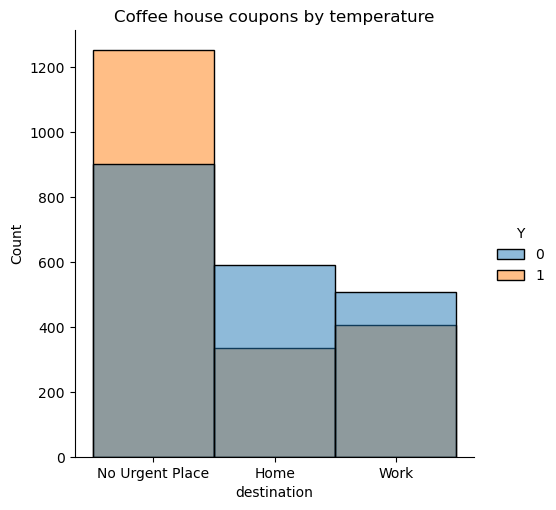

In [65]:
ch_dest_hist = sns.displot(ch_data, x='destination', hue='Y')
ch_dest_hist.set(title='Coffee house coupons by temperature')
ch_dest_hist.savefig('images/coffee/ch_dest_hist.png')

In [66]:
ch_dest_none = ch_data.query('destination == "No Urgent Place"')
ch_dest_none_acc_rate = ch_dest_none['Y'].sum() / ch_dest_none.shape[0]
ch_dest_work_opp = ch_data.query('destination == "Work" and direction_opp == 1')
ch_dest_work_opp_acc_rate = ch_dest_work_opp['Y'].sum() / ch_dest_work_opp.shape[0]
ch_dest_work_same = ch_data.query('destination == "Work" and direction_same == 1')
ch_dest_work_same_acc_rate = ch_dest_work_same['Y'].sum() / ch_dest_work_same.shape[0]
ch_dest_home_opp = ch_data.query('destination == "Home" and direction_opp == 1')
ch_dest_home_opp_acc_rate = ch_dest_home_opp['Y'].sum() / ch_dest_home_opp.shape[0]
ch_dest_home_same = ch_data.query('destination == "Home" and direction_same == 1')
ch_dest_home_same_acc_rate = ch_dest_home_same['Y'].sum() / ch_dest_home_same.shape[0]
print(f"Acceptance rate for people with no urgent place to be: {ch_dest_none_acc_rate*100:.2f}%")
print(f"Acceptance rate for people going to work - if in the opposite direction: {ch_dest_work_opp_acc_rate*100:.2f}%, if in same direction: {ch_dest_work_same_acc_rate*100:.2f}%")
print(f"Acceptance rate for people going home - if in the opposite direction: {ch_dest_home_opp_acc_rate*100:.2f}%, if in same direction: {ch_dest_home_same_acc_rate*100:.2f}%")

Acceptance rate for people with no urgent place to be: 58.10%
Acceptance rate for people going to work - if in the opposite direction: 33.27%, if in same direction: 57.68%
Acceptance rate for people going home - if in the opposite direction: 30.28%, if in same direction: 47.09%


Acceptance rate if unemployed: 54.21%, if student: 62.53%, if in healthcare: 68.35%, if retired: 40.24%, if employed: 47.34%
Acceptance rate if in healthcare and headed to work: 75.00%


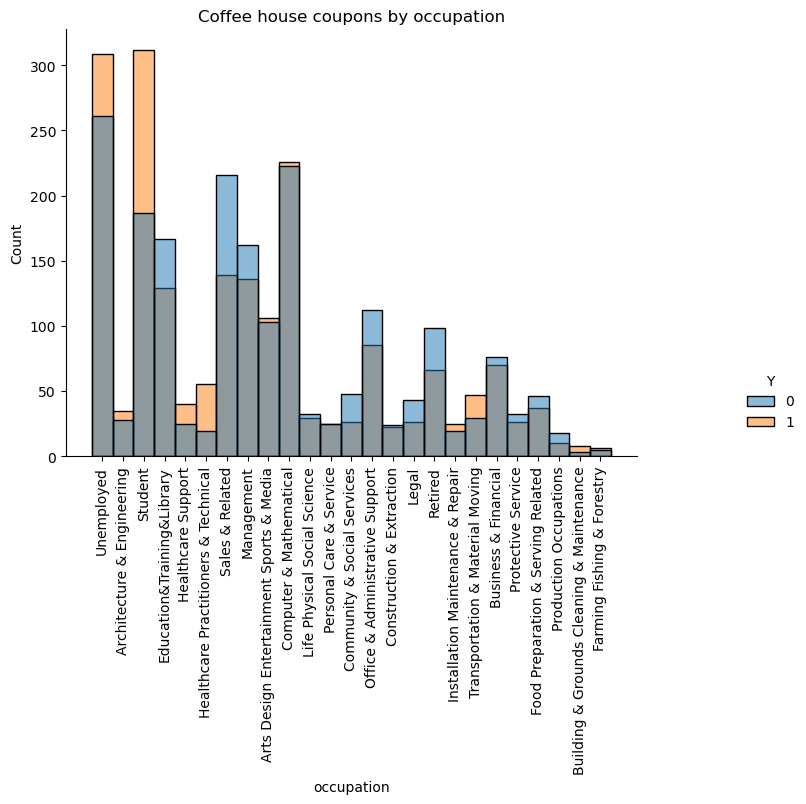

In [69]:
unemp = ch_data.query('occupation == "Unemployed"')
unemp_acc = unemp['Y'].sum() / unemp.shape[0]
student = ch_data.query('occupation == "Student"')
student_acc = student['Y'].sum() / student.shape[0]
retired = ch_data.query('occupation == "Retired"')
retired_acc = retired['Y'].sum() / retired.shape[0]
healthcare = ch_data.query('occupation == "Healthcare Practitioners & Technical" or occupation == "Healthcare Support"')
healthcare_acc = healthcare['Y'].sum() / healthcare.shape[0]
healthcare_to_work = healthcare.query('destination == "Work"')
healthcare_to_work_acc = healthcare_to_work['Y'].sum() / healthcare_to_work.shape[0]
emp = ch_data.query('occupation != "Unemployed" and occupation != "Student" and occupation !="Retired"')
emp_acc = emp['Y'].sum() / emp.shape[0]
print(f"Acceptance rate if unemployed: {unemp_acc*100:.2f}%, if student: {student_acc*100:.2f}%, if in healthcare: {healthcare_acc*100:.2f}%, if retired: {retired_acc*100:.2f}%, if employed: {emp_acc*100:.2f}%")
print(f"Acceptance rate if in healthcare and headed to work: {healthcare_to_work_acc*100:.2f}%")
ch_occupation_hist = sns.displot(ch_data, x='occupation', hue='Y', height=5, aspect=1.5).set(title="Coffee house coupons by occupation")
ch_occupation_hist.tick_params(axis='x', labelrotation=90)
ch_occupation_hist.savefig('images/coffee/ch_occupation_hist.png')

In [70]:
ch_age_lt30 = ch_data.query('age in @age_lt30')
ch_age_lt30_acc_rate = ch_age_lt30['Y'].sum() / ch_age_lt30.shape[0]
ch_age_50plus = ch_data.query('age == "50plus"')
ch_age_50plus_acc_rate = ch_age_50plus['Y'].sum() / ch_age_50plus.shape[0]
ch_other_ages = ch_data.query('age not in @age_lt30 and age != "50plus"')
ch_other_ages_acc_rate = ch_other_ages['Y'].sum() / ch_other_ages.shape[0]
print(f"Acceptance rate for age <30: {ch_age_lt30_acc_rate*100:.2f}%, for age 50+: {ch_age_50plus_acc_rate*100:.2f}%, for ages 30-50: {ch_other_ages_acc_rate*100:.2f}%")

Acceptance rate for age <30: 53.43%, for age 50+: 42.02%, for ages 30-50: 48.47%


In [71]:
ch_temp_80 = ch_data.query('temperature == 80')
ch_temp_80_acc = ch_temp_80['Y'].sum() / ch_temp_80.shape[0]
ch_temp_lt80 = ch_data.query('temperature == 55 or temperature == 30')
ch_temp_lt80_acc = ch_temp_lt80['Y'].sum() / ch_temp_lt80.shape[0]
print(f"Acceptance rate when temperature is 80: {ch_temp_80_acc*100:.2f}%, acceptance rate for lower temps: {ch_temp_lt80_acc*100:.2f}%")

Acceptance rate when temperature is 80: 52.98%, acceptance rate for lower temps: 45.33%


Based on the above analysis, I hypothesize that people are more likely to accept a Coffee House coupon if they go to a coffee house more than 4 times a month (67.5% acceptance rate vs 44% if they go <4 times), and are even more likely to accept if they also have an income of less than 50k. People are also more likely to accept if they have no urgent place to go, if they are going to work or home they are much less likely to accept if the destination is in the opposite direction of where they're headed. Students and people in healthcare professions have the highest acceptance rate based on occupation. People who are under 30 are more likely to accept than people who are older, and people over 50 are the least likely to accept. And the acceptance rate is highest on hotter days (temperature over 80)
Given this data, I'd suggest targeting the coffee house coupons to people who go to coffee shops more than 4 times a month, are under the age of 30, make under 50k a year, and are students, unemployed, or work in healthcare. I'd also suggest sending coupons on days where the temperature is hottest (80 degrees), since the acceptance rate is higher in these instances.